# Dal laboratorio al dispositivo

*Il team di WristMind ha un modello che funziona. Ma il braccialetto non gira su Google Colab: gira su un chip piccolo come un'unghia, con pochi kilobyte di RAM e qualche milliwatt di potenza. Come trasformiamo il nostro modello Keras in qualcosa che possa vivere su quel chip?*

**In questo notebook vedremo tutto il percorso:**
1. Addestriamo il modello finale (compatto e robusto)
2. Lo convertiamo in formato TFLite (TensorFlow Lite)
3. Lo quantizziamo: riduzione del 75% delle dimensioni senza perdere accuratezza
4. Scopriamo come funziona l'inferenza su microcontrollore
5. Confrontiamo le dimensioni e le prestazioni delle tre versioni

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1" 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras

np.random.seed(42)
tf.random.set_seed(42)

print("Carico il dataset HAR...")
har = fetch_openml(data_id=1478, as_frame=True, parser='auto')
X = har.data.astype(np.float32)
y = har.target.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_test_sc  = scaler.transform(X_test).astype(np.float32)

y_train_0 = (y_train - 1).values
y_test_0  = (y_test  - 1).values

print(f"Training: {X_train_sc.shape[0]} campioni, Test: {X_test_sc.shape[0]} campioni")

Carico il dataset HAR...
Training: 7724 campioni, Test: 2575 campioni


## Addestriamo il modello finale

Per il deployment scegliamo un'architettura **bilanciata**: abbastanza profonda da essere accurata, abbastanza piccola da stare nel chip. Aggiungiamo Dropout leggero (0.2) per robustezza.

In [2]:
# Modello finale WristMind: bilanciato tra prestazioni e dimensioni
modello_finale = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(X_train_sc.shape[1],)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(6, activation='softmax')
], name="wristmind_finale")

modello_finale.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Parametri totali: {modello_finale.count_params():,}")
print(f"Dimensione teorica (float32, 4 byte/param): "
      f"{modello_finale.count_params() * 4 / 1024:.1f} KB")
print()

storia = modello_finale.fit(
    X_train_sc, y_train_0,
    epochs=60, batch_size=64, validation_split=0.2, verbose=0
)

_, acc_finale = modello_finale.evaluate(X_test_sc, y_test_0, verbose=0)
print(f"Accuratezza modello finale: {acc_finale:.1%}")

Parametri totali: 80,582
Dimensione teorica (float32, 4 byte/param): 314.8 KB

Accuratezza modello finale: 98.2%


In [3]:
# Salviamo il modello in formato Keras nativo
CARTELLA = "/content" if os.path.exists("/content") else "/tmp"
PATH_KERAS = f"{CARTELLA}/modello_wristmind.keras"

modello_finale.save(PATH_KERAS)
size_keras_kb = os.path.getsize(PATH_KERAS) / 1024
print(f"Modello Keras salvato: {PATH_KERAS}")
print(f"Dimensione su disco: {size_keras_kb:.1f} KB")

Modello Keras salvato: /content/modello_wristmind.keras
Dimensione su disco: 973.5 KB


## TensorFlow Lite: il formato per i dispositivi

Il formato `.keras` non e' progettato per microcontrollori: contiene metadati, strutture dati Python e molto overhead. **TensorFlow Lite** (TFLite) è il formato ottimizzato per dispositivi embedded:

- Struttura dati compatta (FlatBuffer, non JSON)
- Operazioni fusion: più operazioni combinate in una sola
- Nessuna dipendenza da Python o da TensorFlow completo
- Supporto su ARM Cortex-M, ESP32, Arduino Nano 33 BLE, Raspberry Pi

La conversione da Keras a TFLite richiede una sola chiamata API:

In [4]:
# Versione 1: conversione base (pesi in float32, nessuna ottimizzazione)
converter_f32 = tf.lite.TFLiteConverter.from_keras_model(modello_finale)

tflite_f32 = converter_f32.convert()

PATH_TFLITE_F32 = f"{CARTELLA}/wristmind_f32.tflite"
with open(PATH_TFLITE_F32, 'wb') as f:
    f.write(tflite_f32)

size_f32_kb = os.path.getsize(PATH_TFLITE_F32) / 1024
print(f"TFLite float32: {size_f32_kb:.1f} KB")
print(f"Riduzione rispetto a Keras: {(1 - size_f32_kb/size_keras_kb)*100:.0f}%")

TFLite float32: 316.8 KB
Riduzione rispetto a Keras: 67%


## Quantizzazione: da 4 byte a 1 byte per peso

Il trucco più potente per ridurre le dimensioni è la **quantizzazione int8**: i pesi del modello sono rappresentati come interi a 8 bit invece di float a 32 bit. Il risparmio è esattamente **4x**.

Come funziona? Il convertitore TFLite analizza un campione di dati reali (*representative dataset*) per capire il range tipico dei valori di attivazione, e mappa quei valori nel range [-128, 127] degli interi a 8 bit.

La precisione numerica si riduce leggermente (8 bit invece di 32), ma nella pratica l'accuratezza del modello cala pochissimo, spesso anche meno dell'1%.

In [5]:
# Versione 2: quantizzazione int8 (pesi da float32 a int8)
converter_int8 = tf.lite.TFLiteConverter.from_keras_model(modello_finale)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]

# Il "representative dataset" aiuta il convertitore a calibrare la quantizzazione
# Si usa un campione del training set (non serve tutto)
def representative_dataset():
    per_batch = 100  # 100 campioni per batch di calibrazione
    for i in range(0, min(1000, len(X_train_sc)), per_batch):
        batch = X_train_sc[i:i+per_batch]
        yield [batch]

converter_int8.representative_dataset = representative_dataset
# Forziamo int8 anche per input e output (massima ottimizzazione)
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type  = tf.float32  # input resta float per semplicita'
converter_int8.inference_output_type = tf.float32

tflite_int8 = converter_int8.convert()

PATH_TFLITE_INT8 = f"{CARTELLA}/wristmind_int8.tflite"
with open(PATH_TFLITE_INT8, 'wb') as f:
    f.write(tflite_int8)

size_int8_kb = os.path.getsize(PATH_TFLITE_INT8) / 1024
print(f"TFLite int8 quantizzato: {size_int8_kb:.1f} KB")
print(f"Riduzione rispetto a float32: {(1 - size_int8_kb/size_f32_kb)*100:.0f}%")
print(f"Riduzione rispetto a Keras:   {(1 - size_int8_kb/size_keras_kb)*100:.0f}%")

TFLite int8 quantizzato: 86.6 KB
Riduzione rispetto a float32: 73%
Riduzione rispetto a Keras:   91%


## Inferenza TFLite: come funziona il riconoscimento sul chip

Per fare una previsione con il modello TFLite, non si usa il normale `model.predict()`. Si crea un **Interpreter**: un motore di esecuzione leggero che carica il modello, alloca i buffer di memoria, e gestisce input/output.

Questo è esattamente il codice che gira (con le opportune librerie C) su un microcontrollore:

In [6]:
def inferenza_tflite(modello_bytes, X):
    """Esegue inferenza con un modello TFLite su un batch di dati."""
    # Crea l'interprete e alloca i tensori
    interp = tf.lite.Interpreter(model_content=modello_bytes)
    interp.allocate_tensors()

    # Recupera informazioni su input e output
    info_input  = interp.get_input_details()[0]
    info_output = interp.get_output_details()[0]

    predizioni = []
    for campione in X:
        # Prepara il tensore di input: shape (1, 561) con tipo float32
        tensore_in = campione.reshape(1, -1).astype(np.float32)
        interp.set_tensor(info_input['index'], tensore_in)

        # Esegui la forward pass
        interp.invoke()

        # Leggi l'output: vettore di 6 probabilita'
        output = interp.get_tensor(info_output['index'])
        predizioni.append(np.argmax(output))

    return np.array(predizioni)

# Valutiamo l'accuratezza dei due modelli TFLite sul test set
print("Eseguo inferenza TFLite float32...")
y_pred_f32  = inferenza_tflite(tflite_f32,  X_test_sc)
acc_f32 = accuracy_score(y_test_0, y_pred_f32)
print(f"Accuratezza TFLite float32: {acc_f32:.1%}")

print("Eseguo inferenza TFLite int8...")
y_pred_int8 = inferenza_tflite(tflite_int8, X_test_sc)
acc_int8 = accuracy_score(y_test_0, y_pred_int8)
print(f"Accuratezza TFLite int8:    {acc_int8:.1%}")

print(f"\nCalo di accuratezza dalla quantizzazione: {(acc_f32 - acc_int8)*100:.2%}")

Eseguo inferenza TFLite float32...
Accuratezza TFLite float32: 98.2%
Eseguo inferenza TFLite int8...
Accuratezza TFLite int8:    98.2%

Calo di accuratezza dalla quantizzazione: 0.00%


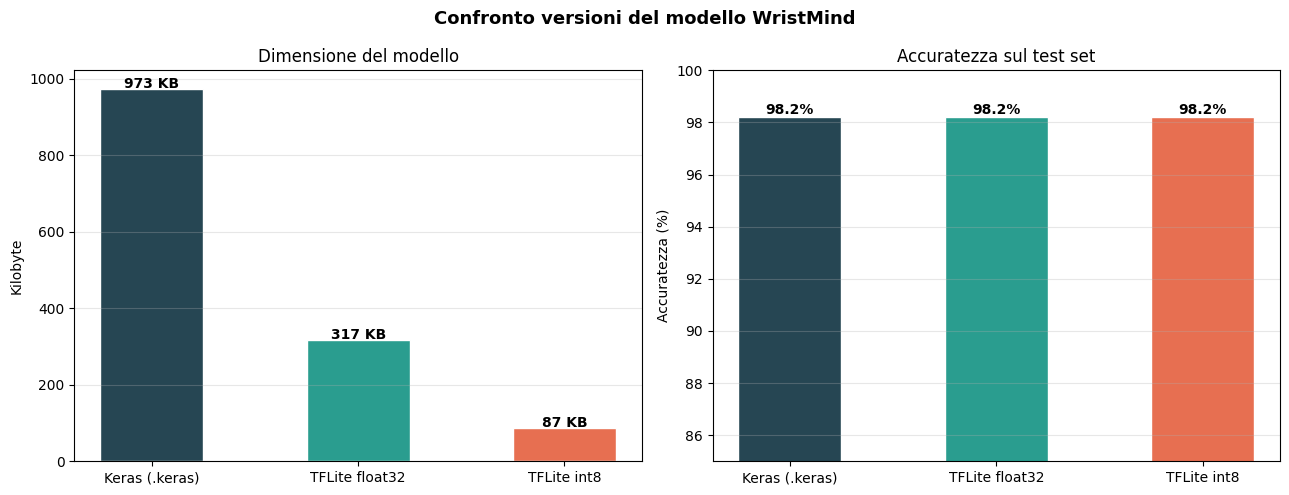

In [7]:
# Confronto visivo: dimensioni e accuratezza delle tre versioni del modello
modelli_nomi   = ["Keras (.keras)", "TFLite float32", "TFLite int8"]
modelli_size   = [size_keras_kb, size_f32_kb, size_int8_kb]
modelli_acc    = [acc_finale * 100, acc_f32 * 100, acc_int8 * 100]
colori         = ['#264653', '#2a9d8f', '#e76f51']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Dimensioni
bars1 = ax1.bar(modelli_nomi, modelli_size, color=colori, width=0.5, edgecolor='white')
ax1.set_ylabel('Kilobyte')
ax1.set_title('Dimensione del modello')
ax1.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, modelli_size):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{val:.0f} KB', ha='center', fontsize=10, fontweight='bold')

# Accuratezza
bars2 = ax2.bar(modelli_nomi, modelli_acc, color=colori, width=0.5, edgecolor='white')
ax2.set_ylabel('Accuratezza (%)')
ax2.set_title('Accuratezza sul test set')
ax2.set_ylim([85, 100])
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, modelli_acc):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.1,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Confronto versioni del modello WristMind',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Tabella riassuntiva: le tre versioni del modello

In [8]:
# Tabella finale comparativa delle tre versioni
df_riepilogo = pd.DataFrame({
    "Versione": [
        "Keras (.keras)",
        "TFLite float32",
        "TFLite int8 quantizzato"
    ],
    "Formato": ["HDF5 + JSON", "FlatBuffer", "FlatBuffer"],
    "Precisione pesi": ["float32 (4 B)", "float32 (4 B)", "int8 (1 B)"],
    "Dimensione (KB)": [
        f"{size_keras_kb:.0f}",
        f"{size_f32_kb:.0f}",
        f"{size_int8_kb:.0f}"
    ],
    "Accuratezza test": [
        f"{acc_finale:.1%}",
        f"{acc_f32:.1%}",
        f"{acc_int8:.1%}"
    ],
    "Destinazione": [
        "Solo sviluppo",
        "Raspberry Pi, telefono",
        "Arduino, ESP32, MCU"
    ]
})
print(df_riepilogo.to_string(index=False))

               Versione     Formato Precisione pesi Dimensione (KB) Accuratezza test           Destinazione
         Keras (.keras) HDF5 + JSON   float32 (4 B)             973            98.2%          Solo sviluppo
         TFLite float32  FlatBuffer   float32 (4 B)             317            98.2% Raspberry Pi, telefono
TFLite int8 quantizzato  FlatBuffer      int8 (1 B)              87            98.2%    Arduino, ESP32, MCU


---

## Deployment su hardware reale: STEdgeAI Developer Cloud

Abbiamo compresso il modello fino a pochi KB. Ma è *davvero* abbastanza piccolo per girare su un microcontrollore da polso?

**STMicroelectronics** mette a disposizione uno strumento gratuito: **STEdgeAI Developer Cloud**.
Permette di:
- **analizzare** il modello (quanto RAM e Flash occupa?)
- **fare il benchmark** su schede STM32 reali, collegate nel cloud (niente hardware fisico!)
- **generare il codice C** per integrare il modello nel firmware

> **Serve un account gratuito**: registrati su https://stedgeai-dc.st.com/home e poi
> inserisci email e password nelle celle che seguono.


### Passo 1 - Installiamo i tool STM32

Scarichiamo le dipendenze direttamente dal repository ufficiale di STMicroelectronics.


In [9]:
import requests, os, sys, shutil, subprocess

# Scarica requirements.txt da STM32 AI Model Zoo Services
raw_url   = 'https://raw.githubusercontent.com/STMicroelectronics/stm32ai-modelzoo-services/main/requirements.txt'
local_req = 'requirements_stm32ai.txt'

resp = requests.get(raw_url, timeout=30)
resp.raise_for_status()
with open(local_req, 'w') as f:
    f.write(resp.text)
print('requirements_stm32ai.txt scaricato.')

# Installa le dipendenze
pip = [sys.executable, '-m', 'pip', 'install', '-q']
subprocess.run([*pip, '-r', local_req], check=True)
subprocess.run([*pip, 'gitdir', 'ipywidgets'], check=True)
print('Dipendenze installate.') 

requirements_stm32ai.txt scaricato.
Dipendenze installate.


### Passo 2 - Token di accesso

Genera il token associato al tuo account ST **una volta** dal tuo PC tramite il file `generate_stm32ai_token.py` che trovi nella cartella `./tokens/` e incollalo qui.

In [ ]:
import json, time
from pathlib import Path

# ⚠️  Incolla qui il Bearer token copiato dal browser (solo il valore, senza "Bearer ")
STM32AI_TOKEN = 'INSERISCI_QUI_IL_TUO_TOKEN'

# Salva il token nel file atteso da stm32ai_dc (~/.stmai_token)
token_file = Path.home() / '.stmai_token'
with open(token_file, 'w') as f:
    json.dump({
        'access_token': STM32AI_TOKEN,
        'refresh_token': None,
        'expires_at': time.time() + 7200,   # valido 2 ore
    }, f)
print(f'Token salvato in {token_file}')


Token salvato in /root/.stmai_token


### Passo 3 - Scarichiamo il modulo `stm32ai_dc`

Il modulo `stm32ai_dc` è una libreria Python che fa da ponte verso lo **STEdgeAI Developer Cloud**.


In [15]:
# Scarica common/stm32ai_dc tramite git sparse-checkout
REPO = 'https://github.com/STMicroelectronics/stm32ai-modelzoo-services.git'
TMP  = '_stm32_tmp'

if os.path.exists(TMP):
    shutil.rmtree(TMP)

subprocess.run(
    ['git', 'clone', '--depth', '1', '--filter=blob:none', '--sparse', REPO, TMP],
    check=True
)
subprocess.run(
    ['git', 'sparse-checkout', 'set', 'common/stm32ai_dc'],
    cwd=TMP, check=True
)

if os.path.exists('./common'):
    shutil.rmtree('./common')
shutil.move(f'{TMP}/common', './common')
shutil.rmtree(TMP, ignore_errors=True)

common_init = './common/__init__.py'
if not os.path.exists(common_init):
    open(common_init, 'w').close()

cwd        = os.path.abspath('.')
common_dir = os.path.abspath('common')
for p in [cwd, common_dir]:
    if p not in sys.path:
        sys.path.insert(0, p)

os.environ['STATS_TYPE'] = 'jupyter_devcloud'
print('Modulo stm32ai_dc pronto!')

Modulo stm32ai_dc pronto!


### Passo 4 - Connessione al cloud e lista schede disponibili


In [16]:
from stm32ai_dc import Stm32Ai, CloudBackend
from common.stm32ai_dc.types import CliParameters   # import canonico: evita conflitti isinstance

ai = Stm32Ai(CloudBackend(None, None, version='4.0.0'))

boards = ai.get_benchmark_boards()
print(f'Connesso! Schede disponibili ({len(boards)} totali):')
for b in boards:
    print(f'  • {b.name}  [{b.deviceCpu}]')


Connesso! Schede disponibili (21 totali):
  • STM32MP257F-EV1  []
  • STM32MP135F-DK  []
  • STM32MP157F-DK2  []
  • STM32F469I-DISCO  [Cortex-M4]
  • NUCLEO-U3C5ZI-Q  [Cortex-M33]
  • STM32L4R9I-DISCO  [Cortex-M4]
  • STM32N6570-DK  [Cortex-M55]
  • STM32H573I-DK  [Cortex-M33]
  • STM32H7B3I-DK  [Cortex-M7]
  • STM32H7S78-DK  [Cortex-M7]
  • NUCLEO-F401RE  [Cortex-M4]
  • NUCLEO-G474RE  [Cortex-M4]
  • B-U585I-IOT02A  [Cortex-M33]
  • NUCLEO-H743ZI2  [Cortex-M7]
  • STM32F769I-DISCO  [Cortex-M7]
  • STM32H735G-DK  [Cortex-M7]
  • STM32H747I-DISCO  [Cortex-M7/M4]
  • LSM6DSO16IS  [Cortex-M4]
  • STM32F746G-DISCO  [Cortex-M7]
  • SR5E1-EVBE3000D  []
  • SR6PX-EVBC4000P  []


### Passo 5 - Benchmark del modello WristMind su schede STM32

Per ogni scheda, il cloud STM32Cube.AI ci restituisce:

| Metrica | Significato |
|---------|-------------|
| **ROM (Flash)** | Spazio occupato dal modello in memoria non-volatile |
| **RAM** | Memoria volatile necessaria durante l'inferenza |
| **MACC** | Multiply-Accumulate operations: misura la complessità computazionale |
| **Tempo inferenza** | Millisecondi per classificare un campione |

Testeremo il modello int8 (il più compatto) su due schede tipiche:
- **NUCLEO-F401RE**: STM32F401, Cortex-M4 a 84 MHz - scheda di sviluppo classica
- **B-U585I-IOT02A**: STM32U5, Cortex-M33 a 160 MHz - ottimizzata per IoT e wearable


In [17]:
def benchmark_su_stm32(percorso_tflite, schede):
    """
    Carica il modello sul cloud STEdgeAI, esegue analisi e benchmark
    sulle schede indicate, poi rimuove il modello dal cloud.
    Restituisce un dizionario {nome_scheda: metriche}.
    """
    nome_file = os.path.basename(percorso_tflite)
    print(f"Caricamento '{nome_file}' sul cloud STM32...")
    ai.upload_model(percorso_tflite)

    risultati = {}
    for scheda in schede:
        print(f'\nBenchmark su {scheda}... ', end='')
        try:
            analisi = ai.analyze(CliParameters(model=nome_file))
            bm      = ai.benchmark(CliParameters(model=nome_file), scheda)
            exec_ms = bm.duration_ms  
            risultati[scheda] = {
                'ROM (KB)':         round(analisi.rom_size / 1024, 1),
                'RAM (KB)':         round(analisi.ram_size / 1024, 1),
                'MACC':             analisi.macc,
                'Tempo inf. (ms)':  round(exec_ms, 2),
            }
            print(f'OK  |  ROM {analisi.rom_size//1024} KB'
                  f'  |  RAM {analisi.ram_size//1024} KB'
                  f'  |  {exec_ms:.2f} ms')
        except Exception as e:
            print(f'Errore: {e}')
            risultati[scheda] = None

    ai.delete_model(nome_file)
    print('\nModello rimosso dal cloud.')
    return risultati


# Eseguiamo il benchmark del modello int8
schede_scelte = ['NUCLEO-F401RE', 'B-U585I-IOT02A']
risultati_wristmind = benchmark_su_stm32(PATH_TFLITE_INT8, schede_scelte)


Caricamento 'wristmind_int8.tflite' sul cloud STM32...

Benchmark su NUCLEO-F401RE... 

Caricamento 'wristmind_int8.tflite' sul cloud STM32...

Benchmark su NUCLEO-F401RE... 

Caricamento 'wristmind_int8.tflite' sul cloud STM32...

Benchmark su NUCLEO-F401RE... 

OK  |  ROM 88 KB  |  RAM 4 KB  |  3.15 ms

Benchmark su B-U585I-IOT02A... 

Caricamento 'wristmind_int8.tflite' sul cloud STM32...

Benchmark su NUCLEO-F401RE... 

OK  |  ROM 88 KB  |  RAM 4 KB  |  3.15 ms

Benchmark su B-U585I-IOT02A... 

Caricamento 'wristmind_int8.tflite' sul cloud STM32...

Benchmark su NUCLEO-F401RE... 

OK  |  ROM 88 KB  |  RAM 4 KB  |  3.15 ms

Benchmark su B-U585I-IOT02A... 

OK  |  ROM 88 KB  |  RAM 4 KB  |  1.63 ms

Modello rimosso dal cloud.


=== Risultati benchmark WristMind int8 su STM32 ===
        Scheda  ROM (KB)  RAM (KB)  MACC  Tempo inf. (ms)
 NUCLEO-F401RE      88.2       4.3 81806             3.15
B-U585I-IOT02A      88.2       4.3 81806             1.63


=== Risultati benchmark WristMind int8 su STM32 ===
        Scheda  ROM (KB)  RAM (KB)  MACC  Tempo inf. (ms)
 NUCLEO-F401RE      88.2       4.3 81806             3.15
B-U585I-IOT02A      88.2       4.3 81806             1.63


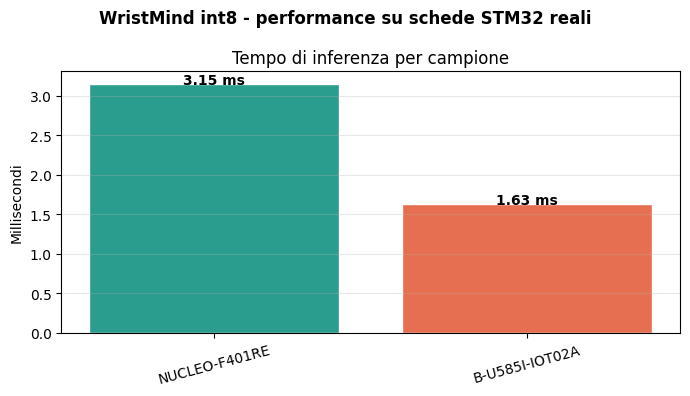

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

righe = []
for scheda, dati in risultati_wristmind.items():
    if dati:
        righe.append({
            'Scheda':            scheda,
            'ROM (KB)':          dati['ROM (KB)'],
            'RAM (KB)':          dati['RAM (KB)'],
            'MACC':              dati['MACC'],
            'Tempo inf. (ms)':   dati['Tempo inf. (ms)'],
        })

if righe:
    df_stm32 = pd.DataFrame(righe)
    print('=== Risultati benchmark WristMind int8 su STM32 ===')
    print(df_stm32.to_string(index=False))

    colori = ['#2a9d8f', '#e76f51', '#264653', '#f4a261']
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.bar(df_stm32['Scheda'], df_stm32['Tempo inf. (ms)'],
           color=colori[:len(righe)], edgecolor='white')
    ax.set_title('Tempo di inferenza per campione')
    ax.set_ylabel('Millisecondi')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(ax.patches, df_stm32['Tempo inf. (ms)']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.2f} ms', ha='center', fontsize=10, fontweight='bold')

    plt.suptitle('WristMind int8 - performance su schede STM32 reali',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Nessun risultato. Controlla le credenziali e la connessione.')


## Il valore dell'Edge AI

Perché fare l'inferenza sul chip invece di inviare i dati a un server cloud?

**Privacy**: i dati grezzi dei sensori rimangono sul dispositivo. Nessun dato personale (come le tue attività quotidiane) viene trasmesso in rete.

**Velocità**: l'inferenza sul chip avviene in pochi millisecondi. Non c'è latenza di rete, nessun ritardo dovuto alla connessione.

**Autonomia**: il dispositivo funziona anche senza connessione internet. Un braccialetto che smette di funzionare in palestra perché non c'è WiFi non è un buon prodotto.

**Energia**: trasmettere dati via Bluetooth o WiFi consuma molto più energia del fare un calcolo sul microcontrollore. L'Edge AI può prolungare la batteria di ore.

---

> **Cosa abbiamo imparato?** Il percorso da un modello Keras a un chip embedded passa attraverso TensorFlow Lite. La conversione preserva la struttura della rete ottimizzandone il formato; la quantizzazione int8 riduce le dimensioni di 4x a costo di un calo minimo di accuratezza. L'inferenza su microcontrollore usa un Interpreter leggero che non dipende da Python né da TensorFlow completo. I modelli TFLite vengono incorporati nel firmware come array C e gira con pochi kilobyte di RAM.

> **Benvenuti nell'ingegneria elettronica e dell'informazione**: In quattro notebook siete passati da un singolo neurone artificiale a un sistema di edge AI funzionante: raccolta dati dai sensori, preprocessing, addestramento di una rete neurale profonda, valutazione delle prestazioni, ottimizzazione e deployment su chip embedded. Questo è un assaggio di quella che è la catena completa del machine learning applicato.